In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from matplotlib.colors import ListedColormap
import seaborn as sns
import matplotlib.pyplot as plt

from brainspace.utils.parcellation import map_to_labels, reduce_by_labels
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import pingouin

In [2]:
bids_folder = '/mnt_04/ds-numrisk' 
plot_folder = op.join(bids_folder, 'plots_and_ims/gradient_stuff')

from os import listdir
subList = [f[4:6] for f in listdir(op.join(bids_folder)) if f[0:4] == 'sub-'] # and len(f)==6]
subList.remove('1')
subList.remove('0')
fsaverage = fetch_surf_fsaverage('fsaverage5') 

In [3]:
from utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(glasser_CAatlas_mapping['ca_network'].values , labeling_glasser, mask=mask_glasser) #, fill=np.nan) #grad_sub[n_grad-1]


In [ ]:
source_folder = op.join(bids_folder, 'derivatives/phenotype')
magjudge_bauer_params_unbiased = pd.read_csv(op.join(source_folder,'bauer-3_sds-maps_unbiased.csv')).set_index('subject')
magjudge_bauer_params = pd.read_csv(op.join(source_folder,'magjudge_bauer-3_sds.csv')).set_index('subject')
magjudge_bauer_params_untrans = pd.read_csv(op.join(source_folder,'magjudge_bauer-3_sds_untransformed.csv')).set_index('subject')

df_behave = magjudge_bauer_params
# all very much the same!

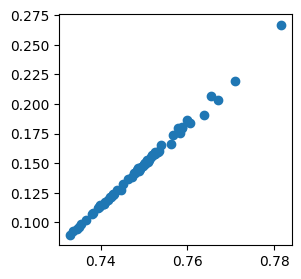

In [60]:
var = 'perceptual_noise_sd'
plt.figure(figsize=(3,3))
plt.scatter(magjudge_bauer_params[var],magjudge_bauer_params_unbiased[var] )

In [51]:
# gradient values, vertex x subject
n_grad = 2

gms_aligned = [None] * len(subList)
for i, sub in enumerate(subList):
    source_folder_gm = op.join(bids_folder,'derivatives','gradients',f'sub-{sub}' )
    gm_aligned = np.load(op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy')) # sub-01_g-aligned_space-fsaverag5_n10.npy
    gms_aligned[i] = gm_aligned[n_grad-1,:] # only one grad to start with

# to create multidimensional array with all subs, grads & parcels, look at asym_grad....
sub_array= np.array([int(i) for i in subList]) 
n_vertices = np.shape(gms_aligned)[1] # 180

In [52]:
g1 = np.array(gms_aligned).T # n_vertices x n_subjects
N_nets = len(np.unique(caNets_fsav5_mapping)[1:]) # remove network-label=0

# compute for each subject and for each yeo network a) network centroid position; b) within network dispersion metric (higher value = wider distribution = more dispersion)
centroids_net = []  # center of gravity (median) for given network (i.e., network centroid position) (7 x 1000)
WN_dispersion = []  # Within network dispersion: sum squared Euclidean distance of network nodes to the network centroid at individual level (7 x 1000)


for n_network in np.unique(caNets_fsav5_mapping)[1:]:
    
    # identify the nodes of given Yeo network
    netNodes = np.where(caNets_fsav5_mapping == (n_network))[0] # get (glasser space) indices
    netNodes = np.squeeze(netNodes)
    
    # get the gradient loadings of the nodes of the given Yeo network, for each subject (shape: number of nodes in network x N)
    G1_net = g1[netNodes]
    
    ### identify the centroid / center of gravity (= median) of the given Yeo network for each subject (shape: N)
    centroid_cog_net = np.nanmedian(G1_net, axis=0)  #np.median(G1_net, axis=0)  
    centroids_net.append(centroid_cog_net)
    
    ### within network dispersion: 1 within network dispersion value per subject (per network)
    
    # compute (per subject) the Eucledian distance between each gradient loading (in Yeo network) and that network's centroid
    dist_nodes_to_centroid = G1_net - centroid_cog_net  # shape: number of nodes in network x N
    
    # take the sum of squares of this Eucledian distance 
    sum_of_squares = np.nanmean((dist_nodes_to_centroid**2), axis = 0)  # shape: N # sum originally!!
    WN_dispersion.append(sum_of_squares)
    
centroids_net = np.array(centroids_net)
WN_dispersion = np.array(WN_dispersion)

In [53]:
df_behave.columns

Index(['memory_noise_sd', 'perceptual_noise_sd'], dtype='object')

In [54]:
# correlation with behavior?!
y_var = 'memory_noise_sd' #'perceptual_noise_sd'
x_var = 'net_distance'

mat_pvals = np.ones([N_nets, N_nets])
mat_rs = np.zeros([N_nets, N_nets])
mat_outliers = np.zeros([N_nets, N_nets])

BN_dispersions = {'pairwise_comparison' : []}
distances = []
for n1 in range(N_nets):
    for n2 in range(N_nets):
        current_pairwise_comparison = [n1+1, n2+1]
        if n1!=n2 and [n1+1, n2+1] not in BN_dispersions['pairwise_comparison'] and list(reversed([n1+1, n2+1])) not in BN_dispersions['pairwise_comparison']:
            BN_dispersions['pairwise_comparison'].append(current_pairwise_comparison)

            distance = centroids_net[n1] - centroids_net[n2] # (12, 66)
            df = pd.DataFrame(np.array(distance.T), index=sub_array,columns=['net_distance'])
            df.index.name = 'subject'
            df_comb = df.join(df_behave)
            cor = pingouin.corr(df_comb[y_var], df_comb[x_var], method = 'shepherd') #defautl: two -sided & pearson 

            mat_rs[n1,n2] = np.round(cor['r'].iloc[0], 2)
            mat_pvals[n1,n2] = np.round(cor['p-val'].iloc[0], 3)
            mat_outliers[n1,n2] = cor['outliers'].iloc[0]

Text(0.5, 1.1, 'Correlation Coefficients of memory_noise_sd with between network distance \n Grad 2')

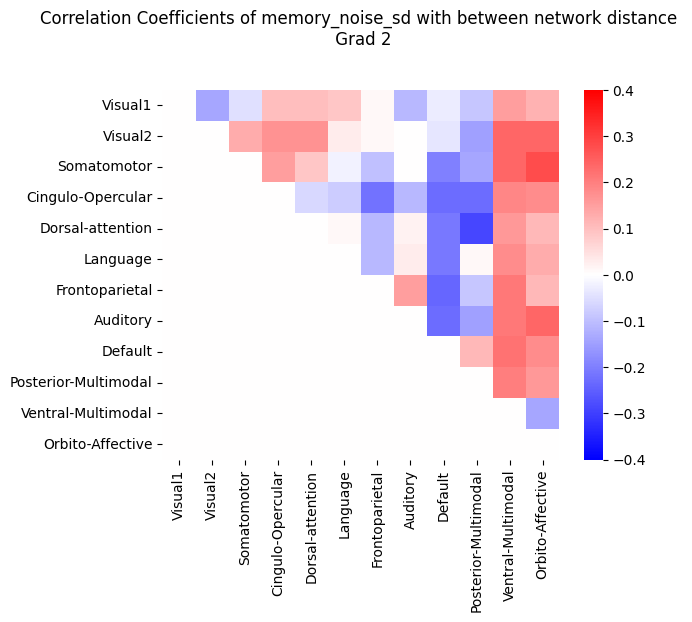

In [55]:
sns.heatmap(mat_rs, cmap='bwr',vmin=-0.4,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Correlation Coefficients of {y_var} with between network distance \n Grad {n_grad}', y=1.1)

Text(0.5, 1.1, 'Correlation P-vals of memory_noise_sd with between network distance \n Grad 2')

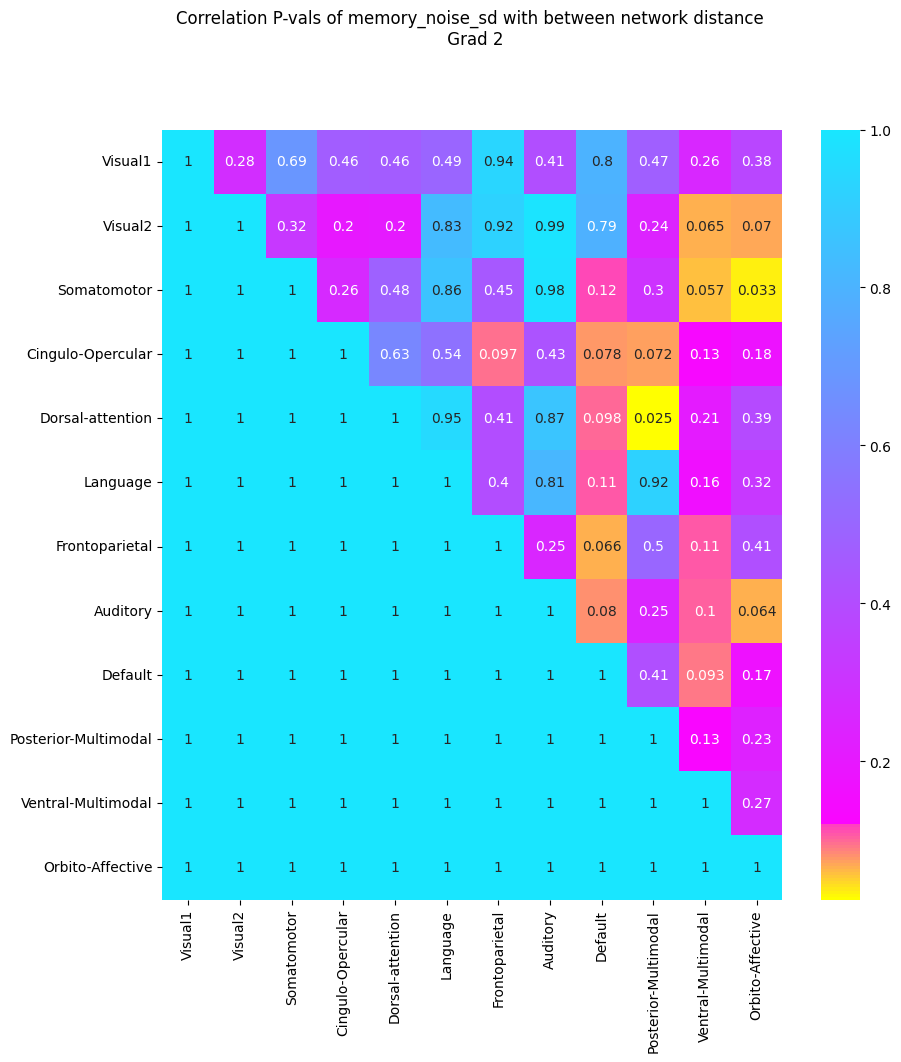

In [56]:
from utils_02 import get_pval_colormap
pval_cmap = get_pval_colormap()

fig, axes = plt.subplots(1,1, figsize=(10,10)) # , sharex=True, sharey=True

sns.heatmap(mat_pvals, cmap=pval_cmap,annot=True,ax=axes, #vmin=-0.4,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Correlation P-vals of {y_var} with between network distance \n Grad {n_grad}', y=1.1)

In [29]:
# gradient values, vertex x subject
gms_aligned_g1 = [None] * len(subList)
gms_aligned_g2 = [None] * len(subList)

for i, sub in enumerate(subList):
    source_folder_gm = op.join(bids_folder,'derivatives','gradients',f'sub-{sub}' )
    gm_aligned = np.load(op.join(source_folder_gm,f'sub-{sub}_g-aligned_space-fsaverag5_n10.npy')) # sub-01_g-aligned_space-fsaverag5_n10.npy
    gms_aligned_g1[i] = gm_aligned[0,:] # only one grad to start with
    gms_aligned_g2[i] = gm_aligned[1,:] # only one grad to start with

# to create multidimensional array with all subs, grads & parcels, look at asym_grad....
sub_array= np.array([int(i) for i in subList]) 
n_vertices = np.shape(gms_aligned_g1)[1] # 

In [35]:
n_grad = 1
gms = gms_aligned_g2 if n_grad == 2 else gms_aligned_g1
df1 = pd.DataFrame(gms_aligned_g1, index=sub_array, columns = [f"vertex_{i+1}" for i in range(np.shape(gms_aligned_g1)[1])])
df2 = pd.DataFrame(gms_aligned_g2, index=sub_array, columns = [f"vertex_{i+1}" for i in range(np.shape(gms_aligned_g1)[1])])
df1.index.name = 'subject'
df2.index.name = 'subject'


In [36]:

df = pd.DataFrame(np.array([df1.mean(axis=0).values,df2.mean(axis=0).values, caNets_fsav5_mapping]).T,
                         columns =['mean_grad1','mean_grad2','ca_network' ]) 

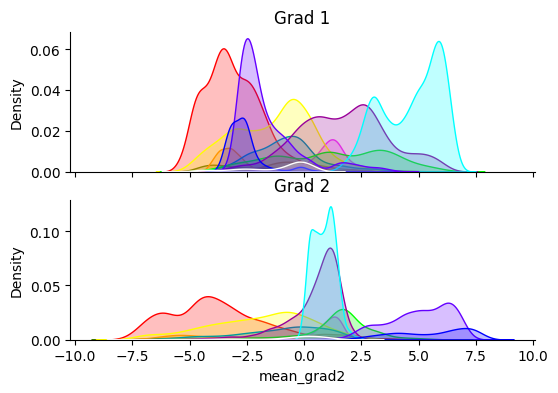

In [41]:
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
ca_cmap = ListedColormap(np.vstack(([1, 1, 1, 1], rgb)), 'custom_colormap') # add white infront, 0=unknown, 1-12 actual labels

fig, axs = plt.subplots(2,1,figsize=(6,4), sharex=True)
sns.kdeplot(df,hue='ca_network',x='mean_grad1',fill=True,palette=ca_cmap,legend=False, ax=axs[0])
sns.kdeplot(df,hue='ca_network',x='mean_grad2',fill=True,palette=ca_cmap,legend=False, ax=axs[1])
axs[0].set(title='Grad 1')
axs[1].set(title='Grad 2')
sns.despine()